# Data Analytics

## Hazmin Chik and Vladyslav Zolotarevskyi

```markdown
## OSMI Mental Health in Tech Survey 2014
```

In [14]:
### Imports & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use("seaborn-v0_8")

DATA_PATH = Path("..") / ".." / "data" / "osmi-raw.csv"
df = pd.read_csv(DATA_PATH)

df.head()
df.info()
df.describe(include='all').transpose()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,1259,1246,2014-08-27 12:43:28,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1259.0,NaN,NaN,NaN,79428148.311358,2818299442.981968,-1726.0,27.0,31.0,36.0,99999999999.0
Gender,1259,49,Male,615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,1259,48,United States,751,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,744,45,CA,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
self_employed,1241,2,No,1095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
family_history,1259,2,No,767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
treatment,1259,2,Yes,637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_interfere,995,4,Sometimes,465,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_employees,1259,6,6-25,290,NaN,NaN,NaN,NaN,NaN,NaN,NaN


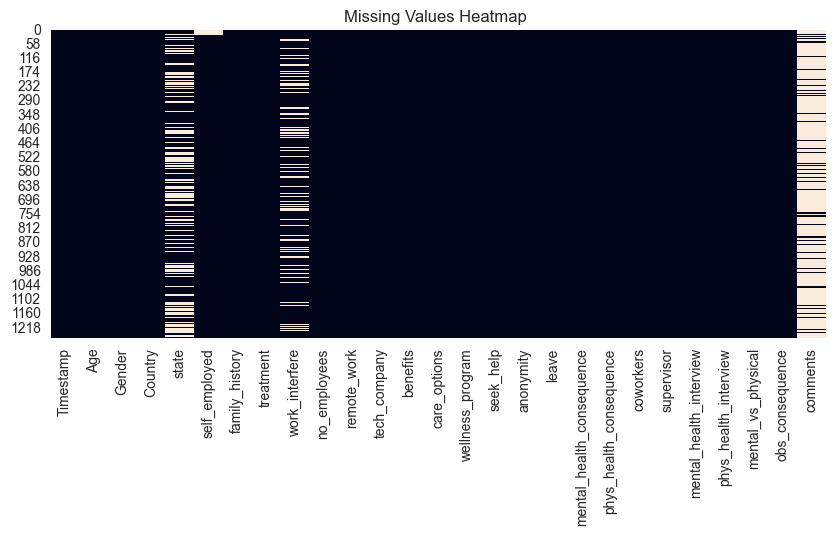

In [15]:
### Missing Values Visualization

plt.figure(figsize=(10,4))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Values Heatmap ")
plt.show()

In [16]:
### Data cleaning and preprocessing
df = df.drop(['comments'], axis= 1)
df = df.drop(['state'], axis= 1)
df = df.drop(['Timestamp'], axis= 1)

# Assign default values for each data type
defaultInt = 0
defaultString = 'NaN'
defaultFloat = 0.0

# Create lists according to data types
integerFeatures = ['Age']
stringFeatures = ['Gender', 'Country', 'self_employed', 'family_history', 'treatment', 'work_interfere',
                 'no_employees', 'remote_work', 'tech_company', 'anonymity', 'leave', 'mental_health_consequence',
                 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview',
                 'mental_vs_physical', 'obs_consequence', 'benefits', 'care_options', 'wellness_program',
                 'seek_help']
floatFeatures = []

# Cleaning NaN's
for i in df:
    if i in integerFeatures:
        df[i] = df[i].fillna(defaultInt)
    elif i in stringFeatures:
        df[i] = df[i].fillna(defaultString)
    elif i in floatFeatures:
        df[i] = df[i].fillna(defaultFloat)
    else:
        print('Error: Feature %s not recognized.' % i)

In [17]:
### Age cleaning

# Replace missing age with median() value
df['Age'] = df['Age'].fillna(df['Age'].median())

# Replace values lower than 18 and higher than 110 with the median
median_age = df['Age'].median()
df.loc[df['Age'] < 18, 'Age'] = median_age
df.loc[df['Age'] > 110, 'Age'] = median_age

# Create age ranges
df['age_range'] = pd.cut(df['Age'], [0, 20, 35, 65, 100], labels=["0-20", "21-35", "36-65", "66-100"], include_lowest=True)
# print(df['Age'].unique())

In [18]:
### Gender cleaning

#To the lowercase 
gender = df['Gender'].str.lower().unique()
#print(gender)

#Gender groups creation
male_str = ["male", "m", "male-ish", "maile", "mal", "male (cis)", "make", "male ", "man","msle", "mail", "malr","cis man", "Cis Male", "cis male"]
other_gender_str = ["trans-female", "something kinda male?", "queer/she/they", "non-binary","nah", "all", "enby", "fluid", "genderqueer", "androgyne", "agender", "male leaning androgynous", "guy (-ish) ^_^", "trans woman", "neuter", "female (trans)", "queer", "ostensibly male, unsure what that really means"]           
female_str = ["female", "woman", "cis female", "f", "femake", "female ","cis-female/femme", "female (cis)", "femail"]

for (row, col) in df.iterrows():

    if str.lower(col.Gender) in male_str:
        df['Gender'].replace(to_replace=col.Gender, value='male', inplace=True)

    if str.lower(col.Gender) in female_str:
        df['Gender'].replace(to_replace=col.Gender, value='female', inplace=True)

    if str.lower(col.Gender) in other_gender_str:
        df['Gender'].replace(to_replace=col.Gender, value='other_gender', inplace=True)

#Removing strange stuff
strange_list = ['A little about you', 'p']
df = df[~df['Gender'].isin(strange_list)]

print(df['Gender'].unique())

['female' 'male' 'other_gender']


In [19]:
### Although 'self_employed' has just 18 NaN values(<2% of all data), we will impute them equally to 'Yes' and 'No' 

# Replace string 'NaN' with actual np.nan
df['self_employed'] = df['self_employed'].replace('NaN', np.nan)

# Get the indices of NaN values
nan_indices = df[df['self_employed'].isna()].index.to_numpy()  # Convert to a numpy array

# Shuffle the indices
np.random.shuffle(nan_indices)

# Split the indices into two halves
half = len(nan_indices) // 2
yes_indices = nan_indices[:half]
no_indices = nan_indices[half:]

# Assign 'Yes' and 'No' to the NaN values
df.loc[yes_indices, 'self_employed'] = 'Yes'
df.loc[no_indices, 'self_employed'] = 'No'

# Check the unique values
print(df['self_employed'].unique())

['Yes' 'No']


In [20]:
#Replace "NaN" string in work_interfere with "Don't know"

df['work_interfere'] = df['work_interfere'].replace([defaultString], 'Don\'t know' )
print(df['work_interfere'].unique())
# print(f"Number of rows with 'NaN': {df[df['work_interfere'] == 'NaN'].shape[0]}")



['Often' 'Rarely' 'Never' 'Sometimes' "Don't know"]


In [21]:
df.head()
df.info()
df.describe(include='all').transpose()

<class 'pandas.core.frame.DataFrame'>
Index: 1257 entries, 0 to 1258
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Age                        1257 non-null   int64   
 1   Gender                     1257 non-null   object  
 2   Country                    1257 non-null   object  
 3   self_employed              1257 non-null   object  
 4   family_history             1257 non-null   object  
 5   treatment                  1257 non-null   object  
 6   work_interfere             1257 non-null   object  
 7   no_employees               1257 non-null   object  
 8   remote_work                1257 non-null   object  
 9   tech_company               1257 non-null   object  
 10  benefits                   1257 non-null   object  
 11  care_options               1257 non-null   object  
 12  wellness_program           1257 non-null   object  
 13  seek_help                  1257 non-nu

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1257.0,NaN,NaN,NaN,32.071599,7.271222,18.0,27.0,31.0,36.0,72.0
Gender,1257,3,male,991,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,1257,47,United States,750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
self_employed,1257,2,No,1104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
family_history,1257,2,No,767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
treatment,1257,2,Yes,635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_interfere,1257,5,Sometimes,465,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_employees,1257,6,6-25,290,NaN,NaN,NaN,NaN,NaN,NaN,NaN
remote_work,1257,2,No,883,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tech_company,1257,2,Yes,1029,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

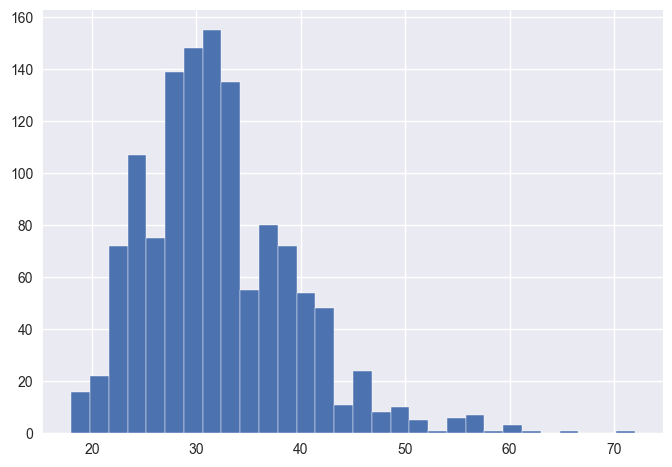

In [22]:
### Age Distribution Histogram

# Strip whitespace
df['Age'] = df['Age'].astype(str).str.strip()

# Replace invalid entries with NaN
invalid_age = ["", " ", "?", "N/A", "none", "None", "nan"]
df['Age'] = df['Age'].replace(invalid_age, pd.NA)

# Convert to numeric properly
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Remove unrealistic ages
df.loc[(df['Age'] < 10) | (df['Age'] > 100), 'Age'] = pd.NA

df['Age'].dropna().hist(bins=30)

In [23]:
### Label Encoding for categorical features

from sklearn import preprocessing

labelDict = {}
for feature in df:
    le = preprocessing.LabelEncoder()
    le.fit(df[feature])
    le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    df[feature] = le.transform(df[feature])
    labelKey = 'label_' + feature
    labelValue = [*le_name_mapping]
    labelDict[labelKey] =labelValue
    
for key, value in labelDict.items():     
    print(key, value)
    
#Remove Country due to too many unique values and lack of importance for the analysis
df = df.drop(['Country'], axis= 1)
df.head()

label_Age [np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(28.0), np.float64(29.0), np.float64(30.0), np.float64(31.0), np.float64(32.0), np.float64(33.0), np.float64(34.0), np.float64(35.0), np.float64(36.0), np.float64(37.0), np.float64(38.0), np.float64(39.0), np.float64(40.0), np.float64(41.0), np.float64(42.0), np.float64(43.0), np.float64(44.0), np.float64(45.0), np.float64(46.0), np.float64(47.0), np.float64(48.0), np.float64(49.0), np.float64(50.0), np.float64(51.0), np.float64(53.0), np.float64(54.0), np.float64(55.0), np.float64(56.0), np.float64(57.0), np.float64(58.0), np.float64(60.0), np.float64(61.0), np.float64(62.0), np.float64(65.0), np.float64(72.0)]
label_Gender ['female', 'male', 'other_gender']
label_Country ['Australia', 'Austria', 'Belgium', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Canada', 'China', 'Colombia', 'C

,Age,Gender,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,age_range
0,19,0,1,0,1,2,4,0,1,2,...,2,1,1,1,2,1,0,2,0,2
1,26,1,1,0,0,3,5,0,0,0,...,0,0,1,0,0,1,1,0,0,2
2,14,1,1,0,0,3,4,0,1,1,...,1,1,1,2,2,2,2,1,0,1
3,13,1,1,1,1,2,2,0,1,1,...,1,2,2,1,0,0,0,1,1,1
4,13,1,0,0,0,1,1,1,1,2,...,0,1,1,1,2,2,2,0,0,1


In [24]:
###Check for missing values
total = df.isnull().sum().sort_values(ascending=False)
percentage = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percentage], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)
print(missing_data)

                           Total  Percent
Age                            0      0.0
Gender                         0      0.0
self_employed                  0      0.0
family_history                 0      0.0
treatment                      0      0.0
work_interfere                 0      0.0
no_employees                   0      0.0
remote_work                    0      0.0
tech_company                   0      0.0
benefits                       0      0.0
care_options                   0      0.0
wellness_program               0      0.0
seek_help                      0      0.0
anonymity                      0      0.0
leave                          0      0.0
mental_health_consequence      0      0.0
phys_health_consequence        0      0.0
coworkers                      0      0.0
supervisor                     0      0.0
mental_health_interview        0      0.0
phys_health_interview          0      0.0
mental_vs_physical             0      0.0
obs_consequence                0  

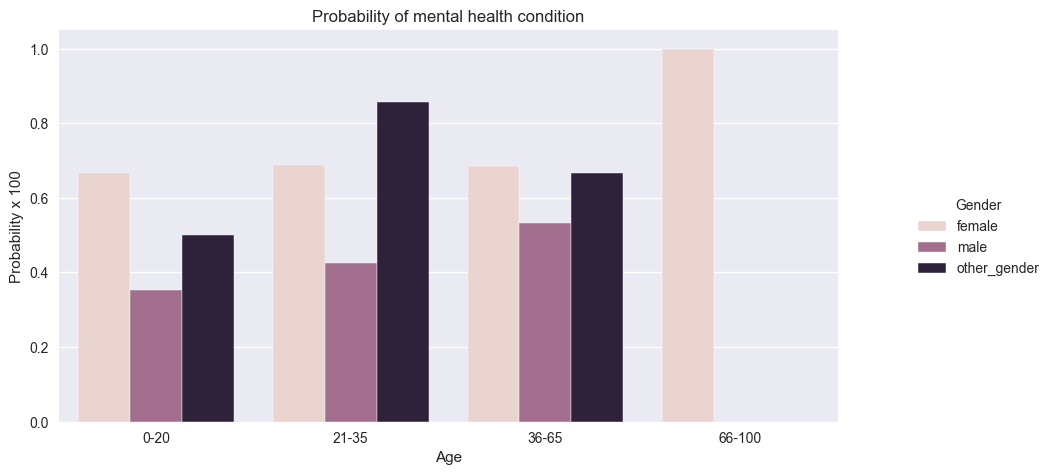

In [25]:
### Probability of mental health condition according to age

o = labelDict['label_age_range']

g = sns.catplot(
    x="age_range", 
    y="treatment", 
    hue="Gender", 
    data=df, 
    kind="bar", 
    errorbar=None, 
    height=5, 
    aspect=2, 
    legend_out=True
)
g.set_xticklabels(o)

plt.title('Probability of mental health condition')
plt.ylabel('Probability x 100')
plt.xlabel('Age')

new_labels = labelDict['label_Gender']
for t, l in zip(g._legend.texts, new_labels): t.set_text(l)

g.fig.subplots_adjust(top=0.9,right=0.8)
plt.show()

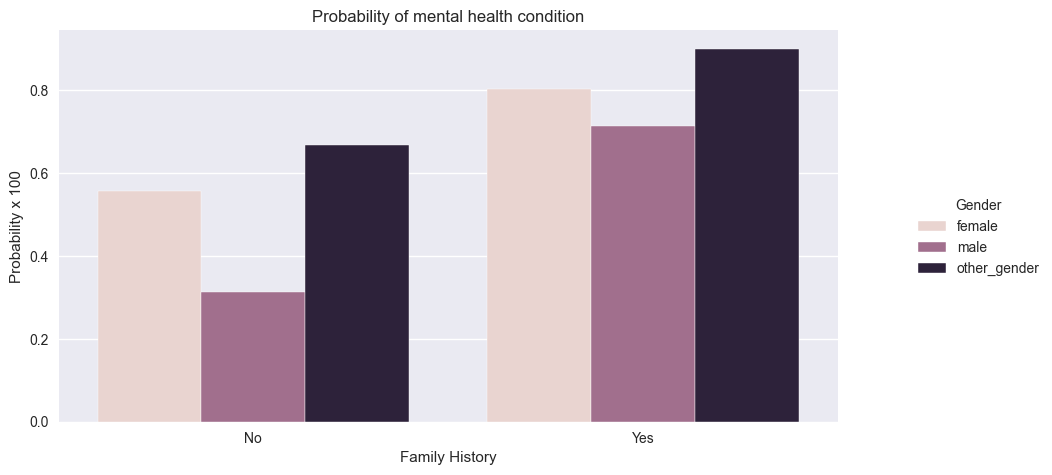

In [26]:
### Probability of mental health condition according to family history
o = labelDict['label_family_history']
g = sns.catplot(
    x="family_history",
    y="treatment",
    hue="Gender",
    data=df,
    kind="bar",
    errorbar=None,  
    height=5,       
    aspect=2,
    legend_out=True
)

g.set_xticklabels(o)

plt.title('Probability of mental health condition')
plt.ylabel('Probability x 100')
plt.xlabel('Family History')

new_labels = labelDict['label_Gender']
for t, l in zip(g._legend.texts, new_labels):
    t.set_text(l)

g.fig.subplots_adjust(top=0.9, right=0.8)
plt.show()